# Advanced Regression Models

## Building Linear Regression Model
We will be using the IPL dataset to discuss advanced regression models. The model will predict SOLD PRICE of a player based on past performance measures of the players.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ipl_auction_df = pd.read_csv('Datasets/IPL.csv')

In [3]:
ipl_auction_df.head()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,...,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,...,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,...,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,...,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,...,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000


In [4]:
ipl_auction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

We will use only a subset of features for building the model. The list X_features is initialized with the name of the features to be used as described below.

In [5]:
X_features = ['AGE', 'COUNTRY', 'PLAYING ROLE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS',
              'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 
              'AVE-BL', 'ECON', 'SR-BL']

Out of these, there are four categorical features that need to be encoded into dummy features using OHE (One Hot Encoding).

In [6]:
categorical_features = ['AGE', 'COUNTRY', 'PLAYING ROLE', 'CAPTAINCY EXP']

encoded_df = pd.get_dummies(ipl_auction_df[X_features], columns=categorical_features, drop_first=True)

In [7]:
encoded_df.columns

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AGE_2', 'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG',
       'COUNTRY_IND', 'COUNTRY_NZ', 'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL',
       'COUNTRY_WI', 'COUNTRY_ZIM', 'PLAYING ROLE_Batsman',
       'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
      dtype='object')

In [8]:
X = encoded_df
Y = ipl_auction_df['SOLD PRICE']

## Standardization of X and Y

Standardization is the process of bringing all features or variables into one single scale (normalized scale). This can be done by subtracting mean from the values and dividing by the standard deviation of the feature or variable. Standardizing helps to manage difference in scales of measurements of different variables.

In [9]:
from sklearn.preprocessing import StandardScaler
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

Y = (Y - Y.mean()) / Y.std()


## Split the Dataset into Training and Test Set

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

## Build the Model

SGDRegressor in sklearn.linear_model is a variation of gradient descent algorithm for building linear regression model. Gradient descent algorithm uses all the training examples to learn to minimize the cost function, whereas SGDRegressor (Stochastic Gradient Descent) uses a subset of examples in each iteration for learning. sklearn.linear_model also provides LinearRegression to build a linear regression model. We can initialize the LinearRegression class and then call fit() and pass X_train and y_train to build the model.

In [11]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
linreg.coef_

array([-0.43539611, -0.04632556,  0.50840867, -0.03323988,  0.2220377 ,
       -0.05065703,  0.17282657, -0.49173336,  0.58571405, -0.11654753,
        0.24880095,  0.09546057,  0.16428731,  0.26400753, -0.08253341,
       -0.28643889, -0.26842214, -0.21910913, -0.02622351,  0.24817898,
        0.18760332,  0.10776084,  0.04737488,  0.05191335,  0.01235245,
        0.00547115, -0.03124706,  0.08530192,  0.01790803, -0.05077454,
        0.18745577])

The sign of the coefficients indicates positive or negative effect on a player’s SOLD PRICE. We will store the beta coefficients and respective column names in a DataFrame and then sort the coefficient values in descending order to observe the effects

In [13]:
columns_coef_df = pd.DataFrame({'columns' : encoded_df.columns, 'coefficients' : linreg.coef_})

sorted_coef = columns_coef_df.sort_values(by='coefficients', ascending=False)

## Plotting the Coefficient Values

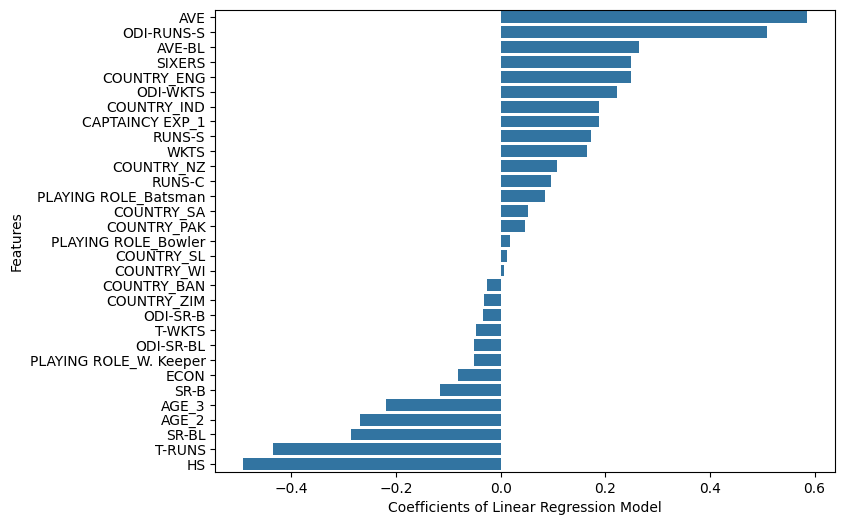

In [15]:
plt.figure(figsize=(8,6))
sns.barplot(x='coefficients', y='columns', data=sorted_coef)
plt.xlabel('Coefficients of Linear Regression Model')
plt.ylabel('Features')
plt.show()

## Observations from above figure
1. AVE, ODI-RUNS-S, AVE-BL are top three highly influential features which determine the player’s SOLD PRICE.
2. Higher ECON, SR-B and AGE have negative effect on SOLD PRICE.
3. Higher test runs (T-RUNS) and highest score (HS) have negative effect on the SOLD PRICE.

## Calculate RMSE

We can calculate the RMSE on training and test sets to understand the model’s ability to predict SOLD PRICE. We will develop an utility method get_train_test_rmse() to calculate and print the RMSE of train and test sets for comparison.

In [16]:
from sklearn import metrics

def get_train_test_rmse(model):
    # Predicting on Train Dataset
    y_train_pred = model.predict(X_train)
    rmse_train = round(np.sqrt(metrics.mean_squared_error(Y_train, y_train_pred)) ,3)

    # Predicting on Test Dataset
    y_test_pred = model.predict(X_test)
    rmse_test = round(np.sqrt(metrics.mean_squared_error(Y_test, y_test_pred)) ,3)
    
    print(f"Train RMSE : {rmse_train}, Test RMSE : {rmse_test}")

In [17]:
get_train_test_rmse(linreg)

Train RMSE : 0.679, Test RMSE : 0.749


RMSE on the training set is 0.679, while it is 0.749 on the test set. A good model that generalizes well needs to have a very similar error on training and test sets. Large difference indicates that the model may be overfitting to the training set. Most widely used approach to deal with model overfitting is called Regularization.

# Regularization

One way to deal with overfitting is regularization. It is observed that overfitting is typically caused by inflation of the coefficients. To avoid overfitting, the coefficients should be regulated by penalizing potential inflation of coefficients. Regularization applies penalties on parameters if they inflate to large values and keeps them from being weighted too heavily. 

The coefficients are penalized by adding the coefficient terms to the cost function. If the coefficients become large, the cost increases significantly. So, the optimizer controls the coefficient values to minimize the cost function. Following are the two approaches that can be used for adding a penalty to the cost function:

1. L1 Norm: Summation of the absolute value of the coefficients. This is also called Least Absolute Shrinkage and Selection Operator (LASSO Term).

2. L2 Norm: Summation of the squared value of the coefficients. This is called Ridge Term.


Ridge term distributes (smoothens) the coefficient values across all the features, whereas LASSO seems to reduce some of the coefficients to zero. Features with coefficients value as zero can be treated as features with no contribution to the model. So, LASSO can also be used for feature selection, that is, remove features with zero coefficients, thereby reducing the number of features.

## Ridge Regression

sklearn.linear_model provides Ridge regression for building linear models by applying L2 penalty.
Ridge regression takes the following parameters:
1. alpha - is the regularization strength; regularization strength must be a positive float.
Regularization improves the estimation of the parameters and reduces the variance of the estimates. Larger values of alpha imply stronger regularization.

2. max_iter - is the maximum number of iterations for the gradient solver.

In [18]:
from sklearn.linear_model import Ridge
# applying the alpha = 1 and running the algorithm for maximum iterations = 500 iterations
ridge = Ridge(alpha=1, max_iter=500)
ridge.fit(X_train, Y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,500
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [19]:
get_train_test_rmse(ridge)

Train RMSE : 0.68, Test RMSE : 0.724


The difference in RMSE on train and test has reduced because of penalty effect. The difference can be reduced by applying a stronger penalty. For example, apply alpha value as 2.0.

In [20]:
ridge = Ridge(alpha=2, max_iter=500)
ridge.fit(X_train, Y_train)

,alpha,2
,fit_intercept,True
,copy_X,True
,max_iter,500
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [21]:
get_train_test_rmse(ridge)

Train RMSE : 0.682, Test RMSE : 0.706


The difference in model accuracy on training and test has reduced. We need to calculate the optimal value for alpha. This can be achieved in many ways. Multiple values of alpha can be tested before arriving at the optimal value. The parameters which can be tuned are called hyperparameters in machine learning. Here alpha is a hyperparameter. sklearn.model_selection.GridSearchCV can help search for the optimal value

## LASSO Regression

sklearn.linear_model provides LASSO regression for building linear models by applying L1 penalty. Two key parameters for LASSO regression are:

1. alpha - multiplies the L1 term. Default value is set to 1.0.
2. max_iter - Maximum number of iterations for gradient solver.

In [22]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01, max_iter=500)
lasso.fit(X_train, Y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,500
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [23]:
get_train_test_rmse(lasso)

Train RMSE : 0.688, Test RMSE : 0.698


It can be noticed that the model is not overfitting and the difference between train RMSE and test RMSE is very small. LASSO reduces some of the coefficient values to 0, which indicates that these features are not necessary for explaining the variance in the outcome variable.
We will store the feature names, coefficient values in a DataFrame and then filter the features with zero coefficients.

In [24]:
# storing the feature names and coefficient values in the dataframe
lasso_coef_df = pd.DataFrame({'columns' : encoded_df.columns, 'coefficients' : lasso.coef_})

lasso_coef_df[lasso_coef_df['coefficients'] == 0]

,columns,coefficients
1,T-WKTS,-0.0
3,ODI-SR-B,-0.0
13,AVE-BL,-0.0
28,PLAYING ROLE_Bowler,0.0


The LASSO regression indicates that the features listed under “columns” are not influencing factors for predicting the SOLD PRICE as the respective coefficients are 0.0.

## Elsetic Net Regression

ElasticNet regression combines both L1 and L2 regularizations to build a regression model. While building ElasticNet regression model, both hyperparameters L2 and L1 need to be set. ElasticNet takes the following two parameters:
1. alpha - Constant that multiplies the penalty terms. Default value is set to 1.0. (alpha = L1 + L2)
2. l1_ratio - The ElasticNet mixing parameter, with 0 <= l1_ratio <= 1.
    where l1_ratio = 0 implies that the penalty is an L2 penalty.
    l1_ratio = 1 implies that it is an L1 penalty.
    0 < l1_ratio < 1 implies that the penalty is a combination of L1 and L2.

In [26]:
from sklearn.linear_model import ElasticNet
enet = ElasticNet(alpha=1.01, l1_ratio=0.001, max_iter=500)
enet.fit(X_train, Y_train)
get_train_test_rmse(enet)

Train RMSE : 0.789, Test RMSE : 0.665


As we can see, applying both the regularizations did not improve the model performance. It has become worse. In this case, we can choose to apply only L1 (LASSO) regularization, which seems to deal with the overfitting problem efficiently.